<a href="https://colab.research.google.com/github/JaskarJeyabalan/customer-segmentation-kmeans/blob/main/notebook/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation using K-Means Clustering

**Problem statement:** segment mall customers by income and spending behaviour so a business can design targeted marketing, improve retention and use its marketing budget better.

> Run this notebook from the `notebooks/` folder (the data path below is relative).

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path("/content/Mall_Customers.csv")
IMAGE_DIR = Path("/content/images")
IMAGE_DIR.mkdir(exist_ok=True)

## 2. Data loading and validation

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape:", df.shape)
print("Missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df.info()

Shape: (200, 5)
Missing values: 0
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Data cleaning
Keep the raw data untouched and rename the columns for readability.

In [5]:
df1 = df.copy()
df1 = df1.rename(columns={"Annual Income (k$)": "Annual Income",
                          "Spending Score (1-100)": "Spending Score"})
df1.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 4. Exploratory data analysis

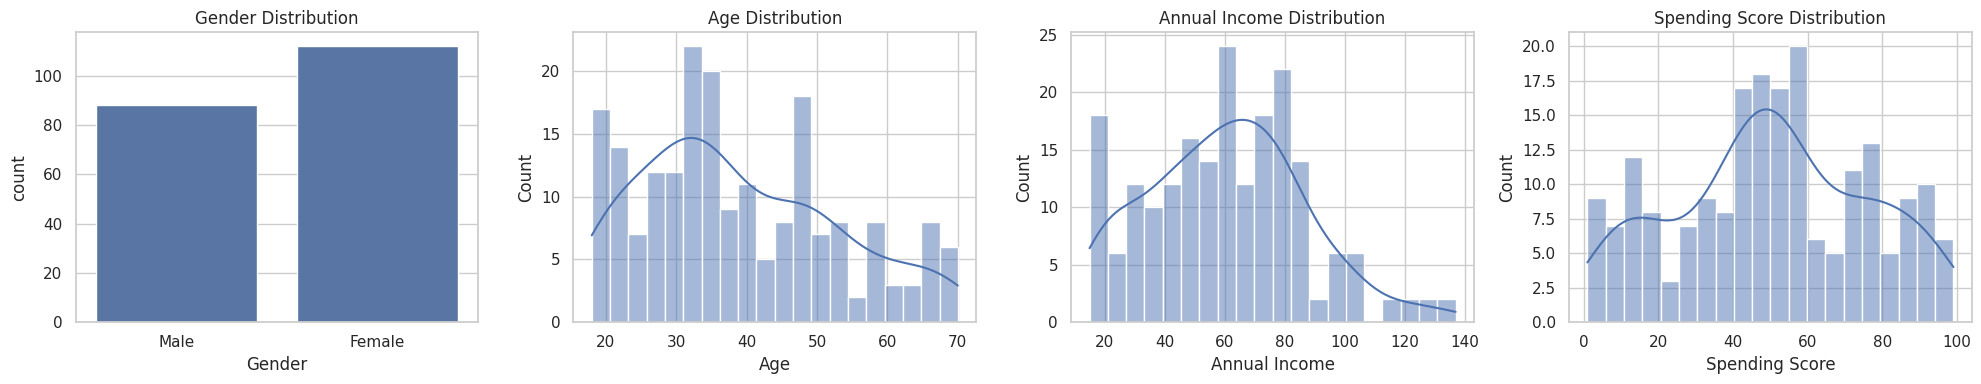

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.countplot(x="Gender", data=df1, ax=axes[0]); axes[0].set_title("Gender Distribution")
for ax, col in zip(axes[1:], ["Age", "Annual Income", "Spending Score"]):
    sns.histplot(df1[col], bins=20, kde=True, ax=ax)
    ax.set_title(f"{col} Distribution")
plt.tight_layout(); plt.show()

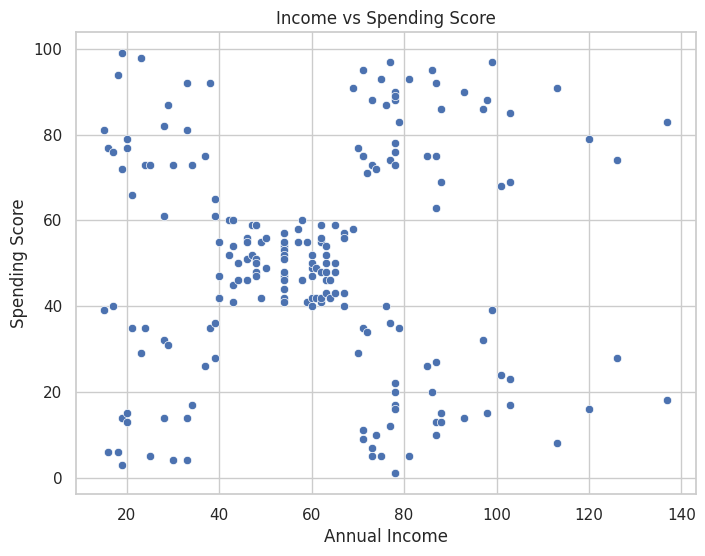

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Annual Income", y="Spending Score", data=df1)
plt.title("Income vs Spending Score")
plt.show()

Correlation heatmap. `CustomerID` is only an identifier, so it is excluded.

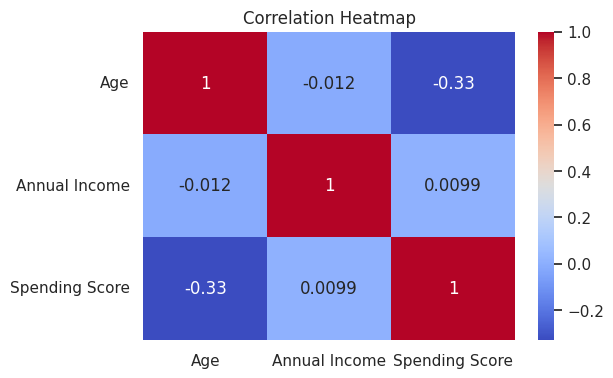

In [8]:
corr = df1[["Age", "Annual Income", "Spending Score"]].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The scatter plot shows visibly distinct groups of customers, and income and spending score are almost uncorrelated, so a linear model would miss this structure. That justifies clustering.

Age is not used for clustering: adding it lowered the silhouette score (about 0.41 vs 0.55), so the 2-feature model separates customers better.

## 5. Feature selection and scaling

In [9]:
features = ["Annual Income", "Spending Score"]
X = df1[features]
X_scaled = StandardScaler().fit_transform(X)

## 6. Choosing k: elbow method and silhouette score

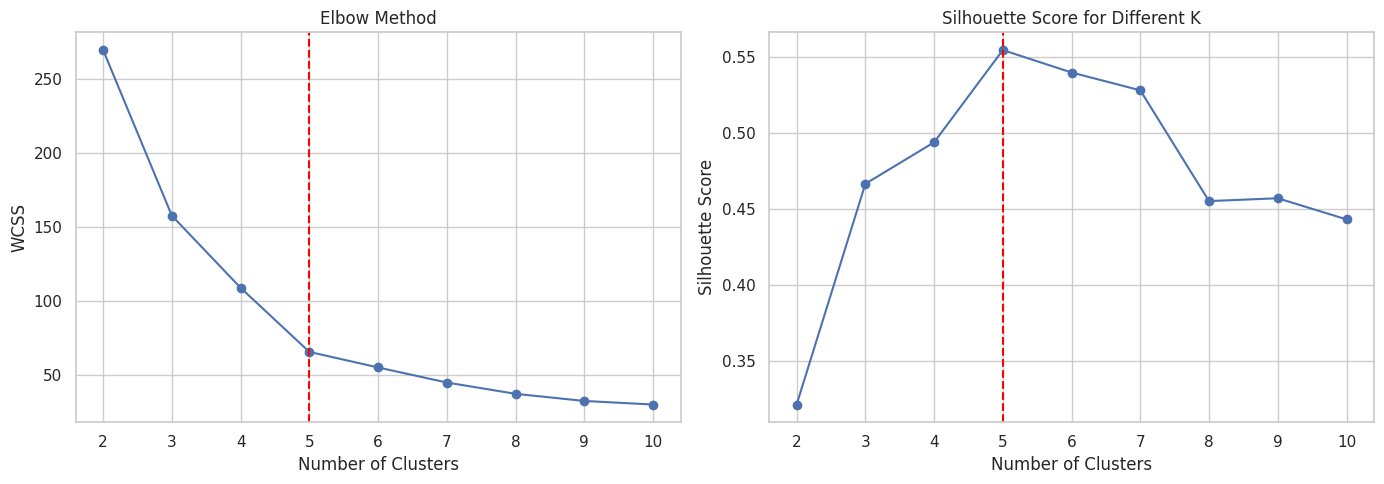

Highest silhouette score: k = 5 (0.555)


In [10]:
k_range = range(2, 11)
wcss, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), wcss, marker="o"); axes[0].axvline(5, color="red", ls="--")
axes[0].set(title="Elbow Method", xlabel="Number of Clusters", ylabel="WCSS")
axes[1].plot(list(k_range), sil_scores, marker="o"); axes[1].axvline(5, color="red", ls="--")
axes[1].set(title="Silhouette Score for Different K", xlabel="Number of Clusters", ylabel="Silhouette Score")
plt.tight_layout(); plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Highest silhouette score: k = {best_k} ({max(sil_scores):.3f})")

The elbow flattens at **k = 5**, and k = 5 also has the highest silhouette score, so both methods agree.

In [11]:
# Save the two charts as separate images for the README
plt.figure(figsize=(8, 5)); plt.plot(list(k_range), wcss, marker="o")
plt.axvline(5, color="red", ls="--", label="k = 5"); plt.title("Elbow Method")
plt.xlabel("Number of Clusters"); plt.ylabel("WCSS"); plt.legend()
plt.savefig(IMAGE_DIR / "elbow_method.png", bbox_inches="tight", dpi=120); plt.close()

plt.figure(figsize=(8, 5)); plt.plot(list(k_range), sil_scores, marker="o")
plt.axvline(5, color="red", ls="--", label="k = 5"); plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters"); plt.ylabel("Silhouette Score"); plt.legend()
plt.savefig(IMAGE_DIR / "silhouette_score.png", bbox_inches="tight", dpi=120); plt.close()

## 7. Fit K-Means (k = 5)

K-Means numbers its clusters arbitrarily, and the numbering can change between runs or scikit-learn versions. So each cluster is named from its centroid values and then mapped to a **fixed ID**. This keeps the cluster numbers, the README and the recommendations consistent.

In [12]:
N_CLUSTERS = 5
SEGMENT_IDS = {
    "Moderate Income, Moderate Spending": 0,
    "High Income, Low Spending": 1,
    "Low Income, High Spending": 2,
    "Low Income, Low Spending": 3,
    "High Income, High Spending": 4,
}

def name_segment(income, spending):
    if 40 <= income <= 70 and 40 <= spending <= 60:
        return "Moderate Income, Moderate Spending"
    inc = "High" if income > 70 else "Low"
    spend = "High" if spending > 50 else "Low"
    return f"{inc} Income, {spend} Spending"

kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE)
raw_labels = kmeans.fit_predict(X_scaled)

# Centroids back in original units (k$ and score)
centroids = pd.DataFrame(
    StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_), columns=features
)
raw_to_name = {i: name_segment(r["Annual Income"], r["Spending Score"]) for i, r in centroids.iterrows()}
assert len(set(raw_to_name.values())) == N_CLUSTERS, raw_to_name

df1["Segment"] = pd.Series(raw_labels).map(raw_to_name)
df1["Cluster"] = df1["Segment"].map(SEGMENT_IDS)
centroids["Cluster"] = centroids.index.map(lambda i: SEGMENT_IDS[raw_to_name[i]])
centroids.sort_values("Cluster")

,Annual Income,Spending Score,Cluster
0,55.296296,49.518519,0
3,88.200000,17.114286,1
2,25.727273,79.363636,2
4,26.304348,20.913043,3
1,86.538462,82.128205,4


## 8. Visualise the clusters

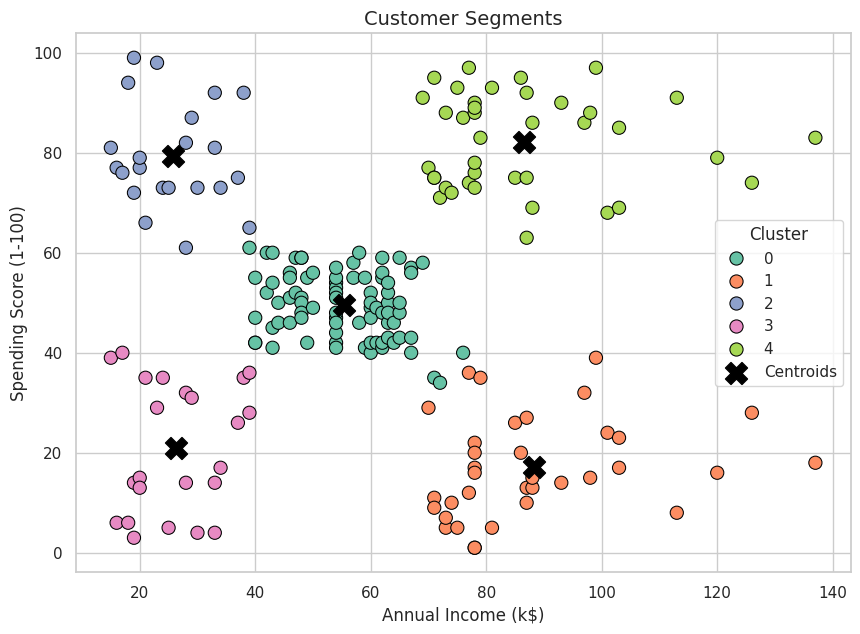

In [13]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df1, x="Annual Income", y="Spending Score", hue="Cluster",
                palette="Set2", s=90, edgecolor="black")
plt.scatter(centroids["Annual Income"], centroids["Spending Score"],
            color="black", marker="X", s=250, label="Centroids")
plt.title("Customer Segments", fontsize=14)
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.savefig(IMAGE_DIR / "clusters.png", bbox_inches="tight", dpi=120)
plt.show()

## 9. Cluster profiling

In [14]:
cluster_profile = (
    df1.groupby(["Cluster", "Segment"])
    .agg(Age=("Age", "mean"), Annual_Income=("Annual Income", "mean"),
         Spending_Score=("Spending Score", "mean"), Customer_Count=("CustomerID", "count"))
    .round(1)
)
cluster_profile

,,Age,Annual_Income,Spending_Score,Customer_Count
Cluster,Segment,,,,
0,"Moderate Income, Moderate Spending",42.7,55.3,49.5,81
1,"High Income, Low Spending",41.1,88.2,17.1,35
2,"Low Income, High Spending",25.3,25.7,79.4,22
3,"Low Income, Low Spending",45.2,26.3,20.9,23
4,"High Income, High Spending",32.7,86.5,82.1,39


## 10. Model evaluation

In [15]:
print("Silhouette Score (k=5):", round(silhouette_score(X_scaled, raw_labels), 3))

Silhouette Score (k=5): 0.555


A silhouette score above 0.5 indicates reasonably well-separated, compact clusters. k = 5 gives the highest score of all values tested (k = 2 to 10).

## 11. Business recommendations

| Cluster | Segment | Strategy |
|---|---|---|
| 0 | Moderate Income, Moderate Spending | Regular offers, loyalty programme, upsell mid-range products |
| 1 | High Income, Low Spending | Personalised campaigns, premium product recommendations, email/SMS outreach to raise conversion |
| 2 | Low Income, High Spending | Discounts, budget bundles, volume-based promotions |
| 3 | Low Income, Low Spending | Keep marketing spend low, target only during major sales |
| 4 | **High Income, High Spending (premium)** | VIP membership, exclusive deals and early access, focus on retention |

## 12. Conclusion

- K-Means found five clear customer groups based on income and spending behaviour.
- Customers do not contribute equally, so segment-specific marketing is more sensible than one campaign for everyone.
- The strategies above are suggestions from the segment profiles. Their impact would need to be tested, for example with A/B campaigns.
- Limitation: this is a small (200 customers), well-known public dataset, so results are for learning and demonstration.